# 3.1.3 平衡方程秩与唯一性

## 学习目标与先修知识

能用独立方程求平衡（equilibrium），区分唯一解、无解和一组平衡，解释封闭系统为什么需要补充守恒总量。

先修：矩阵（matrix）收支（mass balance）、向量（vector）独立性与投影（projection）；一阶模型（model）的平衡含义。 [复习上一节](02-内积范数与投影.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

封闭两室的平衡方程有两行，却无法唯一决定两室所追踪物质总量（tracked amount）。增加一个持续输入（input）和一个清除机制后，为什么又可能有唯一平衡？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK = '#008bfb', '#ff0051'

## 初步实验

先计算一个具体情形，再解释这些数是怎样相互制约的。

In [2]:
M=np.array([[-.2,.1],[.2,-.1]])
for x in [[2,4],[1,2],[0,0]]:
    print('state =',x,'rate =',M@x)
print('第二行恰好等于第一行的相反数。')

state = [2, 4] rate = [0. 0.]
state = [1, 2] rate = [0. 0.]
state = [0, 0] rate = [0. 0.]
第二行恰好等于第一行的相反数。


## 模型假设

仍以总量为状态（state）。封闭情形 a=.2/T、b=.1/T、总量 S=6 U。开放情形输入仅在室 1，清除也仅在室 1，c=.5/T、u=1 U/T；a,b 保持相同。参数（parameter）固定，解的物理可接受性还需检查非负。

## 数学解释与推导

平衡要求**每个**分量的变化率为零。封闭方程是 $-aA_1+bA_2=0$ 和 $aA_1-bA_2=0$，第二行只是第一行乘 −1。秩（rank）数的是独立行或列的数目；这里非零矩阵的秩为 1，而非行数 2。只知道比例 $A_2=(a/b)A_1$ 还不知总量。

补入守恒条件 $A_1+A_2=S$，得到
$$A_1^*=\frac{bS}{a+b},\qquad A_2^*=\frac{aS}{a+b}.$$
S=6 给出 [2,4]。不同总量选择同一条平衡直线上的不同点；如果 a=b=0，向量场（vector field）处处为零，单一总量仍允许很多平衡。

开放时相加两条方程，得到 $u-cA_1^*=0$；再用第二条，得到 $A_2^*=aA_1^*/b$。当 b,c>0，
$$A_1^*=u/c,\qquad A_2^*=au/(bc).$$
一般二维方程 $px+qy=r,\ sx+ty=w$ 中，行列式（determinant） $\Delta=pt-qs$ 测量两个约束是否独立。相乘相减消元得到 $x=(rt-qw)/\Delta$、$y=(pw-rs)/\Delta$；只有 Δ≠0 才能这样除。当前 M 的行列式是 bc。

单位矩阵（identity matrix） I 保持向量不变；逆矩阵（inverse matrix）满足 $M^{-1}M=I$。只有满秩方阵才有逆。实际计算用 `np.linalg.solve(M, -input)` 解线性方程，避免先计算整个逆。奇异不等于无解：零右端可能有无穷多解；封闭交换叠加正输入却没有清除时，总变化率恒正，平衡方程不相容。

数值秩使用浮点容差判断近似独立性。系数接近时还需检查解对小扰动是否敏感。求出平衡位置后，接下来的问题是：系统会不会靠近它，靠近得有多快？

## 核心实现

把刚才的关系逐项写入函数。

In [3]:
def open_equilibrium(a, b, c, u):
    first = u/c
    return [first, a*first/b]
def exchange(a, b, c, u, amounts):
    matrix = [[-a-c, b], [a, -b]]
    first, second = amounts
    rates = [u-(a+c)*first+b*second, a*first-b*second]
    return matrix, rates, sum(rates)

## 对照实验

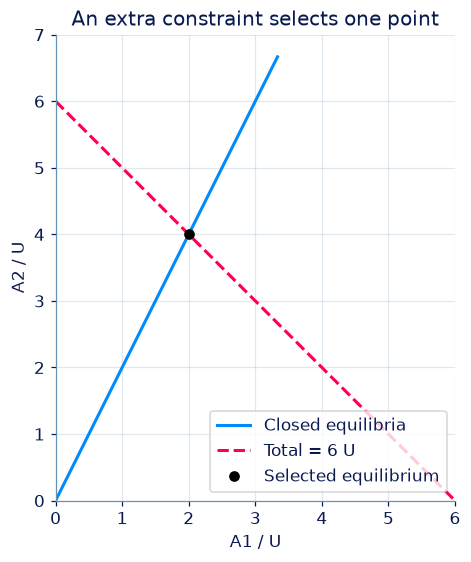

| u / (U/T) | 解方程 A1 / U | 解方程 A2 / U | 收支 A1 / U | 收支 A2 / U |
| --- | --- | --- | --- | --- |
| 0 | -0 | -0 | 0 | 0 |
| 0.5 | 1 | 2 | 1 | 2 |
| 1 | 2 | 4 | 2 | 4 |

In [4]:
totals=np.linspace(0,10,51)
fig,ax=plt.subplots(figsize=(6,5))
ax.plot(totals/3,2*totals/3,color=BLUE,label='Closed equilibria')
ax.plot([0,6],[6,0],'--',color=PINK,label='Total = 6 U')
ax.plot(2,4,'ko',label='Selected equilibrium')
ax.set(xlim=(0,6),ylim=(0,7),xlabel='A1 / U',ylabel='A2 / U',title='An extra constraint selects one point');ax.set_aspect('equal');ax.legend();plt.show()
rows=[]
for u in [0,.5,1]:
    matrix,_,_=exchange(.2,.1,.5,u,[0,0])
    result=np.linalg.solve(matrix,[-u,0])
    rows.append((u,*result,*open_equilibrium(.2,.1,.5,u)))
display(Markdown(show_table(['u / (U/T)','解方程 A1 / U','解方程 A2 / U','收支 A1 / U','收支 A2 / U'],rows)))

## 结果解释

蓝线上的所有点都让封闭系统停止变化；初始总量选定玫红线，两线相交给出 [2,4]。开放模型则由外部收支和室间比例共同确定平衡。

### 独立核对

用收支消元作为库求解的独立依据；再把结果代回原方程。单看矩阵有多少行不能判断信息是否足够。

In [5]:
assert np.linalg.matrix_rank(M)==1
for a,b,c,u in [(.2,.1,.5,1),(0,.3,.2,2),(.8,.4,.1,0)]:
    x=open_equilibrium(a,b,c,u)
    matrix,rates,total=exchange(a,b,c,u,x)
    np.testing.assert_allclose(rates,[0,0],atol=1e-12)
    np.testing.assert_allclose(np.linalg.solve(matrix,[-u,0]),x)
    assert math.isclose(np.linalg.det(matrix),b*c)
print('独立消元、库求解、代回方程和行列式关系一致。')

独立消元、库求解、代回方程和行列式关系一致。


## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：求开放两室的平衡

室 1 接受恒定输入（input） u，并以 cA1 清除；室间交换为 aA1 与 bA2。求非负平衡（equilibrium）所追踪物质总量（tracked amount）。

**函数与代码模板**

```python
def solve(
    a: float,
    b: float,
    c: float,
    u: float,
) -> list[float]:
    # 根据题意计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `a` | `float` | 室 1 到室 2 的交换系数。 | 1/T |
| `b` | `float` | 室 2 到室 1 的交换系数。 | 1/T |
| `c` | `float` | 仅从室 1 清除的系数。 | 1/T |
| `u` | `float` | 仅进入室 1 的恒定输入速率。 | U/T |

**返回值**

直接返回 equilibrium（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `equilibrium` | `list[float]` | [A1*,A2*]。 | U |

**计算规则**

0=u−(a+c)A1*+bA2*；0=aA1*−bA2*。只返回平衡，不返回矩阵（matrix）的逆。

**约束与边界**

- 所有数值有限；不修改输入列表。
- 0≤a≤1；0.05≤b,c≤1；0≤u≤5。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| a | 室 1 到室 2 的交换系数。 | 0.2 | 1/T |
| b | 室 2 到室 1 的交换系数。 | 0.1 | 1/T |
| c | 仅从室 1 清除的系数。 | 0.5 | 1/T |
| u | 仅进入室 1 的恒定输入速率。 | 1 | U/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
a = 0.2
b = 0.1
c = 0.5
u = 1

result = solve(a, b, c, u)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| equilibrium | [A1*,A2*]。 | [2.0, 4.0] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [2.0, 4.0]
```

**样例解释**

相加得 A1*=u/c=2 U；再由交换平衡得 A2*=aA1*/b=4 U。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：求开放两室的平衡](http://127.0.0.1:8000/chapters/03-01-%E4%BB%8E%E5%A4%9A%E4%B8%AA%E5%AE%A4%E8%BF%9B%E5%85%A5%E7%BA%BF%E6%80%A7%E4%BB%A3%E6%95%B0/practice/?question=p03-open-equilibrium)

### 第 2 题 · 单项选择题：封闭系统为何不能直接求逆

a,b>0 的封闭两室交换矩阵（matrix）秩（rank）为 1。要确定从初值（initial condition） [6,0] 出发所对应的平衡（equilibrium），还缺哪一条信息？

- **A.** A1*+A2*=6 U。
- **B.** A1*=A2* 恒成立。
- **C.** 矩阵的每一项都非零。
- **D.** 任意指定 A1*=0。

[作答：封闭系统为何不能直接求逆](http://127.0.0.1:8000/chapters/03-01-%E4%BB%8E%E5%A4%9A%E4%B8%AA%E5%AE%A4%E8%BF%9B%E5%85%A5%E7%BA%BF%E6%80%A7%E4%BB%A3%E6%95%B0/practice/?question=p03-singular-equilibrium)

### 第 3 题 · 多项选择题：秩与解的个数

线性方程 Mx=r 中，以下哪些说法正确？

- **A.** 秩（rank）数的是独立方向或独立约束的数量。
- **B.** 任意奇异矩阵（matrix）都意味着无解。
- **C.** 二维可逆 M 对每个 r 都有唯一解。
- **D.** M=0、r=0 时所有 x 都是解。

[作答：秩与解的个数](http://127.0.0.1:8000/chapters/03-01-%E4%BB%8E%E5%A4%9A%E4%B8%AA%E5%AE%A4%E8%BF%9B%E5%85%A5%E7%BA%BF%E6%80%A7%E4%BB%A3%E6%95%B0/practice/?question=p03-rank-meaning)

### 第 4 题 · 单项选择题：封闭交换加输入能达到定常吗

a,b>0，c=0，u=1 U/T 持续进入室 1。有没有有限的定常所追踪物质总量（tracked amount）？

- **A.** 有，因为两室会均衡。
- **B.** 没有，因为总变化率恒为 1 U/T。
- **C.** 有，只要矩阵（matrix）不可逆。
- **D.** 有，把任何负平衡（equilibrium）设为零即可。

[作答：封闭交换加输入能达到定常吗](http://127.0.0.1:8000/chapters/03-01-%E4%BB%8E%E5%A4%9A%E4%B8%AA%E5%AE%A4%E8%BF%9B%E5%85%A5%E7%BA%BF%E6%80%A7%E4%BB%A3%E6%95%B0/practice/?question=p03-no-clearance-input)

### 第 5 题 · 多项选择题：计算出平衡就算完成了吗

由 Mx*+[u,0]=0 得到 x*=[2,4]。接下来哪些检查有意义？

- **A.** 把 x* 代回两条原方程。
- **B.** 核对输入（input）与清除的总账。
- **C.** 仅凭方程有解，就断言所有初值（initial condition）必在有限时间到达。
- **D.** 区分平衡（equilibrium）存在、稳定性与到达速度。

[作答：计算出平衡就算完成了吗](http://127.0.0.1:8000/chapters/03-01-%E4%BB%8E%E5%A4%9A%E4%B8%AA%E5%AE%A4%E8%BF%9B%E5%85%A5%E7%BA%BF%E6%80%A7%E4%BB%A3%E6%95%B0/practice/?question=p03-equilibrium-limit)

**进一步阅读**

[Boyd 与 Vandenberghe：应用线性代数](https://web.stanford.edu/~boyd/vmls/)：向量、范数、独立性与线性方程。